In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    DistilBertModel,
)

import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Basic setup
# -------------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# >>> IMPORTANT: repo root path (folder where README.md, data/, outputs/ unnayi)
base = Path("/content/ML-disaster-tweets")   # left side pane lo same name untundi
print("Base path:", base)

fig_dir = base / "outputs" / "figs"
metrics_dir = base / "outputs" / "metrics"

for d in [fig_dir, metrics_dir]:
    os.makedirs(d, exist_ok=True)
    print("OK - folder exists:", d)


Using device: cuda
Base path: /content/ML-disaster-tweets
OK - folder exists: /content/ML-disaster-tweets/outputs/figs
OK - folder exists: /content/ML-disaster-tweets/outputs/metrics


In [2]:
from google.colab import files
import os, shutil
import pandas as pd
from pathlib import Path

# ----------------------------------------------------------
# 1) Find the repo folder under /content  (handles -1, -2 etc)
# ----------------------------------------------------------
root = Path("/content")
candidates = [p for p in root.iterdir()
              if p.is_dir() and "ML-disaster-tweets" in p.name]

if not candidates:
    raise FileNotFoundError(
        "Repo folder not found under /content. "
        "Run the git clone cell first."
    )

base = candidates[0]
print("Using repo root:", base)

# ----------------------------------------------------------
# 2) Make sure data/raw/train.csv exists (else upload it)
# ----------------------------------------------------------
train_path = base / "data" / "raw" / "train.csv"
print("Expected train.csv path:", train_path)

if not train_path.exists():
    print(" train.csv not found in the repo.")
    print("Please select train.csv from your laptop (Kaggle file).")
    uploaded = files.upload()              # pick train.csv
    os.makedirs(train_path.parent, exist_ok=True)
    shutil.move("train.csv", str(train_path))
    print("✅ Copied train.csv to:", train_path)

# ----------------------------------------------------------
# 3) Load the data
# ----------------------------------------------------------
df = pd.read_csv(train_path)
print("Data shape:", df.shape)
df.head()


Using repo root: /content/ML-disaster-tweets
Expected train.csv path: /content/ML-disaster-tweets/data/raw/train.csv
Data shape: (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


Class counts:
 target
0    4342
1    3271
Name: count, dtype: int64


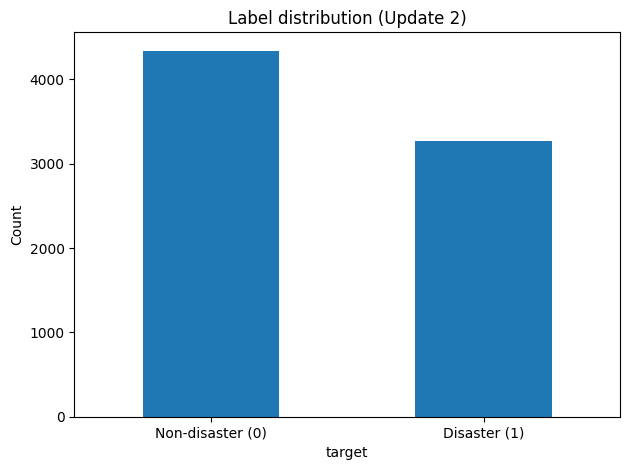

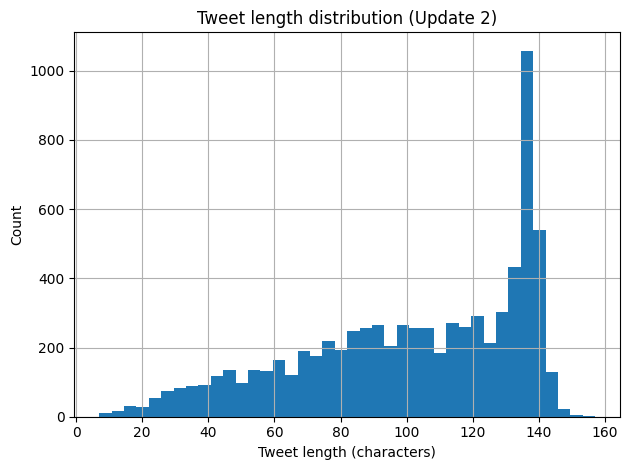

In [3]:
# -------------------------------------------------------------------
# Simple label distribution and tweet length visualisations
# -------------------------------------------------------------------
df["len_text"] = df["text"].astype(str).str.len()

class_counts = df["target"].value_counts().sort_index()
print("Class counts:\n", class_counts)

plt.figure()
class_counts.plot(kind="bar")
plt.xticks([0, 1], ["Non-disaster (0)", "Disaster (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Label distribution (Update 2)")
plt.tight_layout()
plt.savefig(fig_dir / "class_balance_update2.png")
plt.show()

plt.figure()
df["len_text"].hist(bins=40)
plt.xlabel("Tweet length (characters)")
plt.ylabel("Count")
plt.title("Tweet length distribution (Update 2)")
plt.tight_layout()
plt.savefig(fig_dir / "tweet_length_update2.png")
plt.show()


In [4]:
# -------------------------------------------------------------------
# Train / validation split
# -------------------------------------------------------------------
X = df["text"].astype(str).tolist()
y = df["target"].astype(int).tolist()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

len(X_train), len(X_val)


(6090, 1523)

In [5]:
# -------------------------------------------------------------------
# Tokenizer + Dataset + DataLoaders
# -------------------------------------------------------------------
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

MAX_LEN = 128
BATCH_SIZE = 16

class TweetDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_ds = TweetDataset(X_train, y_train)
val_ds   = TweetDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [6]:
# -------------------------------------------------------------------
# Evaluation helper for single-task DistilBERT
# -------------------------------------------------------------------
def evaluate_single(model, data_loader):
    model.eval()
    preds, labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in data_loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            y = batch["labels"].to(device)

            out = model(
                input_ids=ids,
                attention_mask=mask,
                labels=y,
            )
            total_loss += out.loss.item()
            pred = out.logits.argmax(dim=1)

            preds.extend(pred.cpu().tolist())
            labels.extend(y.cpu().tolist())

    avg_loss = total_loss / len(data_loader)
    acc = accuracy_score(labels, preds)

    return avg_loss, acc, labels, preds

In [7]:
# -------------------------------------------------------------------
# Single-task DistilBERT: training
# -------------------------------------------------------------------
model_single = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
).to(device)

optimizer_single = torch.optim.AdamW(model_single.parameters(), lr=2e-5)

EPOCHS = 3
train_losses_s = []
val_losses_s = []
val_accs_s = []
best_acc_single = 0.0

for ep in range(EPOCHS):
    model_single.train()
    total_train_loss = 0.0

    for batch in train_loader:
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        y = batch["labels"].to(device)

        optimizer_single.zero_grad()
        out = model_single(
            input_ids=ids,
            attention_mask=mask,
            labels=y,
        )
        loss = out.loss
        loss.backward()
        optimizer_single.step()

        total_train_loss += loss.item()

    # validation
    val_loss, val_acc, y_true_s, y_pred_s = evaluate_single(model_single, val_loader)

    train_losses_s.append(total_train_loss)
    val_losses_s.append(val_loss)
    val_accs_s.append(val_acc)

    print(
        f"[Single] Epoch {ep+1}/{EPOCHS} | "
        f"Train Loss={total_train_loss:.3f} | Val Loss={val_loss:.3f} | Val Acc={val_acc:.4f}"
    )

    if val_acc > best_acc_single:
        best_acc_single = val_acc
        torch.save(model_single.state_dict(), base / "bestsingle.pt")
        print("  -> Saved bestsingle.pt (best Val Acc so far)")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Single] Epoch 1/3 | Train Loss=168.423 | Val Loss=0.371 | Val Acc=0.8450
  -> Saved bestsingle.pt (best Val Acc so far)
[Single] Epoch 2/3 | Train Loss=125.753 | Val Loss=0.365 | Val Acc=0.8529
  -> Saved bestsingle.pt (best Val Acc so far)
[Single] Epoch 3/3 | Train Loss=88.910 | Val Loss=0.440 | Val Acc=0.8280


In [8]:
# -------------------------------------------------------------------
# Reload best single-task model and export metrics
# -------------------------------------------------------------------
# reload best weights (safety)
model_single.load_state_dict(
    torch.load(base / "bestsingle.pt", map_location=device)
)
model_single.to(device)

best_loss_single, best_acc_single, y_true_s, y_pred_s = evaluate_single(
    model_single, val_loader
)
f1_single = f1_score(y_true_s, y_pred_s)

print("Best single-task Val loss:", best_loss_single)
print("Best single-task Val accuracy:", best_acc_single)
print("Best single-task F1 score:", f1_single)

# classification report -> CSV
report_single = classification_report(
    y_true_s,
    y_pred_s,
    output_dict=True,
    digits=4,
)
df_single_rep = pd.DataFrame(report_single).T
df_single_rep.to_csv(metrics_dir / "single_update2_report.csv", index=True)

# summary metrics table
df_single_summary = pd.DataFrame(
    {
        "metric": ["val_loss", "val_accuracy", "f1_score"],
        "value": [best_loss_single, best_acc_single, f1_single],
    }
)
df_single_summary.to_csv(metrics_dir / "single_update2_summary.csv", index=False)

df_single_summary


Best single-task Val loss: 0.36495597070703906
Best single-task Val accuracy: 0.8529218647406435
Best single-task F1 score: 0.8187702265372169


,metric,value
0,val_loss,0.364956
1,val_accuracy,0.852922
2,f1_score,0.818770


In [9]:
# -------------------------------------------------------------------
# Build auxiliary task: tweet length bucket (0 = short, 1 = medium, 2 = long)
# -------------------------------------------------------------------
def length_bucket(text: str) -> int:
    L = len(text)
    if L < 60:
        return 0
    elif L < 120:
        return 1
    else:
        return 2

aux_train = [length_bucket(t) for t in X_train]
aux_val   = [length_bucket(t) for t in X_val]

# quick check of distribution
pd.Series(aux_train).value_counts().sort_index()


,count
0,872
1,2818
2,2400


In [10]:
# -------------------------------------------------------------------
# Multi-task Dataset + DataLoaders
# -------------------------------------------------------------------
class MultiTaskDataset(Dataset):
    def __init__(self, texts, y_main, y_aux):
        self.texts = texts
        self.y_main = y_main
        self.y_aux = y_aux

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "main": torch.tensor(self.y_main[idx], dtype=torch.long),
            "aux": torch.tensor(self.y_aux[idx], dtype=torch.long),
        }

train_m = MultiTaskDataset(X_train, y_train, aux_train)
val_m   = MultiTaskDataset(X_val, y_val, aux_val)

train_loader_m = DataLoader(train_m, batch_size=BATCH_SIZE, shuffle=True)
val_loader_m   = DataLoader(val_m, batch_size=32, shuffle=False)


In [11]:
class DistilBertMulti(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")

        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.3)

        # main task: disaster (0/1)
        self.main_head = nn.Linear(hidden_size, 2)
        # aux task: length bucket (0/1/2)
        self.aux_head = nn.Linear(hidden_size, 3)

        self.loss_main = nn.CrossEntropyLoss()
        self.loss_aux = nn.CrossEntropyLoss()

    def forward(self, ids, mask, y_main=None, y_aux=None):
        out = self.bert(input_ids=ids, attention_mask=mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])

        main_logits = self.main_head(cls)
        aux_logits  = self.aux_head(cls)

        if y_main is None:
            # inference mode
            return main_logits, aux_logits

        loss_m = self.loss_main(main_logits, y_main)
        loss_a = self.loss_aux(aux_logits, y_aux)

        loss = loss_m + 0.5 * loss_a
        return loss, main_logits, aux_logits


In [12]:
# ---------------------------------------------------------
# Evaluate multi-task model (main task only)
# ---------------------------------------------------------
def evaluate_mtl(model, loader):
    model.eval()
    total_loss = 0.0
    all_y_true, all_y_pred = [], []

    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            y_m  = batch["main"].to(device)   # <--- MAIN LABELS
            y_a  = batch["aux"].to(device)    # <--- AUX LABELS

            # model returns: loss, main_logits, aux_logits
            loss, main_logits, _ = model(ids, mask, y_m, y_a)
            total_loss += loss.item()

            preds = torch.argmax(main_logits, dim=1).cpu().numpy()
            all_y_pred.extend(preds)
            all_y_true.extend(y_m.cpu().numpy())

    acc = accuracy_score(all_y_true, all_y_pred)
    f1  = f1_score(all_y_true, all_y_pred)

    return acc, f1, total_loss / len(loader)


# ---------------------------------------------------------
# Train multi-task DistilBERT (Update 2)
# ---------------------------------------------------------
epochs = 3
train_losses_m = []
val_accs_m = []
val_f1s_m = []

model_m = DistilBertMulti().to(device)
optim_m = torch.optim.AdamW(model_m.parameters(), lr=2e-5)

for ep in range(1, epochs + 1):
    model_m.train()
    total_loss = 0.0

    for batch in train_loader_m:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        y_m  = batch["main"].to(device)   # <--- MAIN LABELS
        y_a  = batch["aux"].to(device)    # <--- AUX LABELS

        optim_m.zero_grad()

        # model returns: loss, main_logits, aux_logits
        loss, _, _ = model_m(ids, mask, y_m, y_a)
        loss.backward()
        optim_m.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_m)
    train_losses_m.append(avg_loss)

    # quick val accuracy each epoch (using main task)
    val_acc_m, val_f1_m, _ = evaluate_mtl(model_m, val_loader_m)
    val_accs_m.append(val_acc_m)
    val_f1s_m.append(val_f1_m)

    print(f"Epoch {ep}/{epochs} | "
          f"TrainLoss={avg_loss:.4f} | "
          f"ValAcc={val_acc_m:.4f} | "
          f"ValF1={val_f1_m:.4f}")


Epoch 1/3 | TrainLoss=0.7331 | ValAcc=0.8352 | ValF1=0.8065
Epoch 2/3 | TrainLoss=0.4452 | ValAcc=0.8267 | ValF1=0.8036
Epoch 3/3 | TrainLoss=0.3168 | ValAcc=0.8378 | ValF1=0.7950


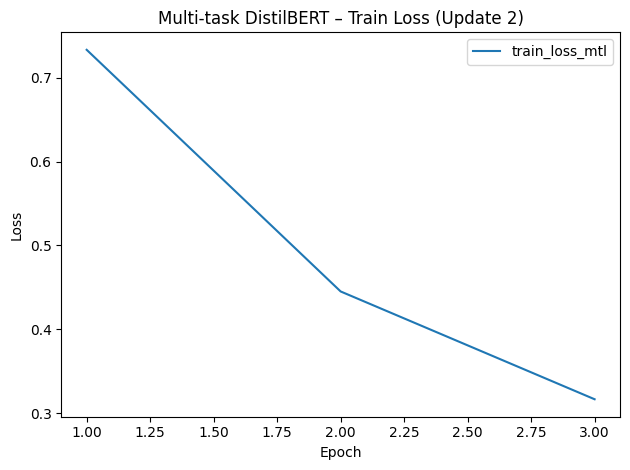

In [13]:
# -------------------------------------------------------------------
# Paths for figures / metrics + MTL loss curve (Update 2)
# -------------------------------------------------------------------
from pathlib import Path
import matplotlib.pyplot as plt

# repo base (same as before)
base = Path("/content/ML-disaster-tweets")

fig_dir = base / "outputs" / "figs"
metrics_dir = base / "outputs" / "metrics"
fig_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

# x-axis for epochs
epochs_range = range(1, len(train_losses_m) + 1)

plt.figure()
plt.plot(epochs_range, train_losses_m, label="train_loss_mtl")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Multi-task DistilBERT – Train Loss (Update 2)")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "loss_curve_mtl_update2.png")
plt.show()


In [14]:
import pandas as pd
import pathlib as pl

fig_dir = pl.Path("outputs/figs")
metrics_dir = fig_dir / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

df_mtl = pd.DataFrame({
    "epoch": [1, 2, 3],
    "train_loss": train_losses_m,
    "val_acc": val_accs_m,
    "val_f1": val_f1s_m,
})

df_mtl.to_csv(metrics_dir / "distilbert_mtl_update2.csv", index=False)

print("Saved to:", metrics_dir / "distilbert_mtl_update2.csv")


Saved to: outputs/figs/metrics/distilbert_mtl_update2.csv


In [16]:
import numpy as np
import pandas as pd

# basic epoch-wise summary
epochs_arr = np.arange(1, len(train_losses_m) + 1)

summary_df = pd.DataFrame({
    "epoch": epochs_arr,
    "train_loss_mtl": train_losses_m,
    "val_acc_mtl": val_accs_m,
    "val_f1_mtl": val_f1s_m,
})

display(summary_df)

# compact comparison: first vs last epoch + best metrics
comparison_df = pd.DataFrame({
    "Metric": [
        "Train loss (epoch 1)",
        "Train loss (epoch last)",
        "Val acc (epoch 1)",
        "Val acc (epoch last)",
        "Best val acc (any epoch)",
        "Best val F1 (any epoch)",
    ],
    "Value": [
        train_losses_m[0],
        train_losses_m[-1],
        val_accs_m[0],
        val_accs_m[-1],
        max(val_accs_m),
        max(val_f1s_m),
    ]
})

display(comparison_df)

,epoch,train_loss_mtl,val_acc_mtl,val_f1_mtl
0,1,0.733061,0.835194,0.806476
1,2,0.445230,0.826658,0.803571
2,3,0.316834,0.837820,0.795021


,Metric,Value
0,Train loss (epoch 1),0.733061
1,Train loss (epoch last),0.316834
2,Val acc (epoch 1),0.835194
3,Val acc (epoch last),0.837820
4,Best val acc (any epoch),0.837820
5,Best val F1 (any epoch),0.806476
